In [ ]:
import sys

from models.bsm import bsm_price, bsm_greeks, bsm_greeks_fd
from models.binomial import crr_price# Try a slightly OTM call
crr_otm = [crr_price(100, 105, 1.0, 0.05, 0.20, N, 'call') for N in [50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]]
bsm_otm = bsm_price(100, 105, 1.0, 0.05, 0.20, 'call')
print(f"BSM OTM = {bsm_otm:.6f}")
for N, p in zip(range(50, 61), crr_otm):
    print(f"N={N}: CRR = {p:.6f}, error = {p - bsm_otm:+.4e}")
import numpy as np

BSM OTM = 8.021352
N=50: CRR = 8.014263, error = -7.0893e-03
N=51: CRR = 8.050251, error = +2.8899e-02
N=52: CRR = 8.010671, error = -1.0681e-02
N=53: CRR = 8.050381, error = +2.9029e-02
N=54: CRR = 8.007251, error = -1.4101e-02
N=55: CRR = 8.050319, error = +2.8966e-02
N=56: CRR = 8.003990, error = -1.7362e-02
N=57: CRR = 8.050093, error = +2.8741e-02
N=58: CRR = 8.000876, error = -2.0476e-02
N=59: CRR = 8.049730, error = +2.8378e-02
N=60: CRR = 7.997898, error = -2.3454e-02


In [2]:
# Benchmark 1: Single option (canonical case)
price = bsm_price(S=100, K=100, T=1.0, r=0.05, sigma=0.20, option_type='call')
print(f"Single ATM call: {price}")

# Benchmark 2: Vector of strikes
strikes = np.array([80, 90, 100, 110, 120])
prices = bsm_price(S=100, K=strikes, T=1.0, r=0.05, sigma=0.20, option_type='call')
print(f"Vector of strikes: {prices}")
print(f"Shape: {prices.shape}")

# Benchmark 3: 2D grid (the real test of broadcasting)
strikes = np.array([90, 100, 110])         # shape (3,)
maturities = np.array([[0.25], [0.5], [1.0], [2.0]])  # shape (4, 1)
grid = bsm_price(S=100, K=strikes, T=maturities, r=0.05, sigma=0.20, option_type='call')
print(f"\nGrid shape: {grid.shape}")
print(f"Grid:\n{grid}")

Single ATM call: 10.450583572185565
Vector of strikes: [24.58883544 16.69944841 10.45058357  6.04008813  3.24747742]
Shape: (5,)

Grid shape: (4, 3)
Grid:
[[11.67008669  4.61499713  1.19113166]
 [13.49851748  6.88872858  2.90647132]
 [16.69944841 10.45058357  6.04008813]
 [22.03338001 16.12677972 11.45545587]]


In [3]:
# Benchmark 4: Put-Call Parity 2D grid 
C = bsm_price(S=100, K=strikes, T=maturities, r=0.05, sigma=0.20, option_type='call')
P = bsm_price(S=100, K=strikes, T=maturities, r=0.05, sigma=0.20, option_type='put')
parity_residual = C - P - 100 + strikes * np.exp(-0.05 * maturities)
MAR = np.max(np.abs(parity_residual))
print(f"\nGrid shape: {parity_residual.shape}")
print(f"Grid:\n{parity_residual}")
print(f"\nMax Absolute Residual: {MAR}")
assert MAR <= 1e-10



Grid shape: (4, 3)
Grid:
[[ 0.00000000e+00  0.00000000e+00  1.42108547e-14]
 [-1.42108547e-14  0.00000000e+00  1.42108547e-14]
 [ 0.00000000e+00  0.00000000e+00 -1.42108547e-14]
 [ 1.42108547e-14  1.42108547e-14  0.00000000e+00]]

Max Absolute Residual: 1.4210854715202004e-14


# Black-Scholes-Merton Greeks Reference

For a European option on a non-dividend-paying underlying, with:
- $S$ = spot price
- $K$ = strike price  
- $T$ = time to expiry (years)
- $r$ = risk-free rate (continuously compounded)
- $\sigma$ = volatility (annualised)

Define:

$$d_1 = \frac{\ln(S/K) + (r + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

Where $\Phi$ is the standard normal CDF and $\varphi$ is the standard normal PDF:

$$\Phi(x) = \int_{-\infty}^x \frac{1}{\sqrt{2\pi}} e^{-y^2/2}\, dy, \qquad \varphi(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$$

---

## Prices

$$C = S\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2)$$

$$P = K e^{-rT}\,\Phi(-d_2) - S\,\Phi(-d_1)$$

**Put-call parity:** $C - P = S - K e^{-rT}$

---

## First-Order Greeks

### Delta — sensitivity to spot, $\Delta = \partial V/\partial S$

$$\Delta_{\text{call}} = \Phi(d_1) \in (0, 1)$$

$$\Delta_{\text{put}} = \Phi(d_1) - 1 = -\Phi(-d_1) \in (-1, 0)$$

**Interpretation:** number of units of the underlying to hold to delta-hedge a short option position. ATM call has $\Delta \approx 0.5$; deep ITM call $\Delta \to 1$; deep OTM $\Delta \to 0$.

**Parity:** $\Delta_{\text{call}} - \Delta_{\text{put}} = 1$ (differentiate put-call parity in $S$).

---

### Vega — sensitivity to volatility, $\mathcal{V} = \partial V/\partial \sigma$

$$\mathcal{V}_{\text{call}} = \mathcal{V}_{\text{put}} = S\, \varphi(d_1)\, \sqrt{T}$$

**Interpretation:** how much option price changes per unit change in $\sigma$. Always positive. Identical for calls and puts (put-call parity has no $\sigma$ term).

**Convention:** "vega" is not a real Greek letter. Sometimes written $\nu$. Quoted as raw value (per unit $\sigma$); divide by 100 for "per vol point" (per 0.01 change in $\sigma$).

**Peak:** ATM-forward, decays into ITM/OTM. Long-dated options have larger Vega.

---

### Theta — sensitivity to time, $\Theta = \partial V/\partial t$

For calendar-time convention (time *advancing*, $T$ decreasing):

$$\Theta_{\text{call}} = -\frac{S\,\varphi(d_1)\,\sigma}{2\sqrt{T}} - r K e^{-rT}\,\Phi(d_2)$$

$$\Theta_{\text{put}} = -\frac{S\,\varphi(d_1)\,\sigma}{2\sqrt{T}} + r K e^{-rT}\,\Phi(-d_2)$$

**Interpretation:** how much value the option loses per unit of calendar time. Almost always negative for long positions ("time decay"). Most negative for ATM short-dated options. Divide by 365 for daily theta.

**Common term:** $-S\varphi(d_1)\sigma / (2\sqrt{T})$ — same for call and put (variance-decay term). Differs only in the interest-rate effect.

**Sign convention warning:** some sources define $\Theta = \partial V/\partial T$ (positive for long options). The trader convention is $\partial V/\partial t$ (negative for long options). Make sure you know which one.

---

### Rho — sensitivity to interest rate, $\rho = \partial V/\partial r$

$$\rho_{\text{call}} = K\, T\, e^{-rT}\, \Phi(d_2)$$

$$\rho_{\text{put}} = -K\, T\, e^{-rT}\, \Phi(-d_2)$$

**Interpretation:** how much option price changes per unit change in $r$. Positive for calls, negative for puts. Typically the smallest Greek in normal markets — dominates only for long-dated options or sharp rate moves. Divide by 100 for "per 1% rate change."

---

## Second-Order Greek

### Gamma — sensitivity of Delta to spot, $\Gamma = \partial^2 V/\partial S^2 = \partial \Delta / \partial S$

$$\Gamma_{\text{call}} = \Gamma_{\text{put}} = \frac{\varphi(d_1)}{S\,\sigma\,\sqrt{T}}$$

**Interpretation:** how curved the price function is in $S$. Equivalently, how often you need to rebalance a delta hedge. Always non-negative for vanillas. Identical for calls and puts.

**Peak:** ATM and *short-dated*. As $T \to 0$ for ATM, $\Gamma \to \infty$ (the kink at $K$ becomes infinitely sharp).

**Trading interpretation:** long Gamma = profit from any underlying move (convexity), but pay Theta as the cost. Short Gamma = collect Theta but bleed on moves.

---

## The BSM PDE Identity

Every BSM Greek satisfies:

$$\Theta + \frac{1}{2}\sigma^2 S^2\, \Gamma + r S\, \Delta - r V = 0$$

This is the BSM PDE written in Greek notation. Useful as a single-line correctness check: compute all Greeks plus the price, plug into the LHS, expect zero (to machine precision) for analytic Greeks.

**Gamma–Theta trade-off:** for a delta-hedged portfolio ($\Delta = 0$), the PDE simplifies to:

$$\Theta = -\frac{1}{2}\sigma^2 S^2\, \Gamma + rV$$

Positive Gamma is "paid for" with negative Theta. If realised vol exceeds implied (the σ in your Theta calc), Gamma profit > Theta cost over a small step → you make money. This is the entire mathematical basis of delta-hedged volatility trading.

---

## Summary Table

| Greek | Call | Put | Sign (long position) |
|---|---|---|---|
| Delta $\Delta$ | $\Phi(d_1)$ | $\Phi(d_1) - 1$ | $+$ (call) / $-$ (put) |
| Gamma $\Gamma$ | $\dfrac{\varphi(d_1)}{S\sigma\sqrt{T}}$ | same | $+$ |
| Vega $\mathcal{V}$ | $S\varphi(d_1)\sqrt{T}$ | same | $+$ |
| Theta $\Theta$ | $-\dfrac{S\varphi(d_1)\sigma}{2\sqrt{T}} - rKe^{-rT}\Phi(d_2)$ | $-\dfrac{S\varphi(d_1)\sigma}{2\sqrt{T}} + rKe^{-rT}\Phi(-d_2)$ | $-$ |
| Rho $\rho$ | $KTe^{-rT}\Phi(d_2)$ | $-KTe^{-rT}\Phi(-d_2)$ | $+$ (call) / $-$ (put) |

**Identity:** $\Theta + \tfrac{1}{2}\sigma^2 S^2 \Gamma + rS\Delta - rV = 0$ for both calls and puts.

---

## Higher-Order Greeks (not used today, for reference)

| Name | Definition | Use |
|---|---|---|
| Vanna | $\partial^2 V / (\partial S\, \partial\sigma)$ | Vega's sensitivity to spot moves; FX hedging |
| Volga (Vomma) | $\partial^2 V / \partial \sigma^2$ | Vega's sensitivity to vol moves; convexity in vol |
| Charm | $\partial^2 V / (\partial S \,\partial t)$ | Delta decay per unit time |
| Speed | $\partial^3 V / \partial S^3$ | Gamma's sensitivity to spot |
| Color | $\partial^2 \Gamma / \partial t$ or $\partial^3 V / (\partial S^2 \partial t)$ | Gamma decay |

These matter for: exotic options, large books, vol surface dynamics. You may meet Vanna and Volga in Week 6 (SABR calibration intuition).

In [4]:
# Greek Test 
# Example:
S = 100
K = 100
T = 1
r = 0.05
sigma = 0.2

call_price = bsm_price(S, K, T, r, sigma, option_type='call')
put_price = bsm_price(S, K, T, r, sigma, option_type='put')

print(f"Call Price: {call_price:.4f}")
print(f"Put Price: {put_price:.4f}")

call_greeks = bsm_greeks(S, K, T, r, sigma, option_type='call')
put_greeks = bsm_greeks(S, K, T, r, sigma, option_type='put')

print("Call Greeks:", call_greeks)
print("Put Greeks:", put_greeks)

# Call PDE test 
print("Call PDE Test:")
print(call_greeks['theta'] + 0.5 * sigma**2 * S**2 * call_greeks['gamma'] + r * S * call_greeks['delta'] - r * call_price)

Call Price: 10.4506
Put Price: 5.5735
Call Greeks: {'delta': np.float64(0.6368306511756191), 'gamma': np.float64(0.018762017345846895), 'vega': np.float64(37.52403469169379), 'theta': np.float64(-6.414027546438197), 'rho': np.float64(53.232481545376345)}
Put Greeks: {'delta': np.float64(-0.3631693488243809), 'gamma': np.float64(0.018762017345846895), 'vega': np.float64(37.52403469169379), 'theta': np.float64(-1.657880423934626), 'rho': np.float64(-41.89046090469506)}
Call PDE Test:
-2.220446049250313e-16


In [5]:
# Greek Test with Finite Difference Comparison
# Example:
S = 100
K = 100
T = 1
r = 0.05
sigma = 0.2

call_greeks_fd = bsm_greeks_fd(S, K, T, r, sigma, option_type='call', h = 1e-4)
put_greeks_fd = bsm_greeks_fd(S, K, T, r, sigma, option_type='put', h = 1e-4)
call_diff = {k: abs(call_greeks_fd[k] - call_greeks[k]) for k in call_greeks}
put_diff = {k: abs(put_greeks_fd[k] - put_greeks[k]) for k in put_greeks}

print("Call Greeks:", call_greeks)
print("Put Greeks:", put_greeks)
print("Call Greeks FD:", call_greeks_fd)
print("Put Greeks FD:", put_greeks_fd)
print("Abs Diff - Call:", call_diff)
print("Abs Diff - Put:", put_diff)

Call Greeks: {'delta': np.float64(0.6368306511756191), 'gamma': np.float64(0.018762017345846895), 'vega': np.float64(37.52403469169379), 'theta': np.float64(-6.414027546438197), 'rho': np.float64(53.232481545376345)}
Put Greeks: {'delta': np.float64(-0.3631693488243809), 'gamma': np.float64(0.018762017345846895), 'vega': np.float64(37.52403469169379), 'theta': np.float64(-1.657880423934626), 'rho': np.float64(-41.89046090469506)}
Call Greeks FD: {'delta': np.float64(0.6368306511816968), 'gamma': np.float64(0.018761880937745445), 'vega': np.float64(37.52403438721075), 'theta': np.float64(-6.414027551358004), 'rho': np.float64(53.23248077413467)}
Put Greeks FD: {'delta': np.float64(-0.36316934885149976), 'gamma': np.float64(0.018761880937745445), 'vega': np.float64(37.52403438721075), 'theta': np.float64(-1.6578804288513993), 'rho': np.float64(-41.89046183441292)}
Abs Diff - Call: {'delta': np.float64(6.0776939037054944e-12), 'gamma': np.float64(1.3640810144974203e-07), 'vega': np.float6

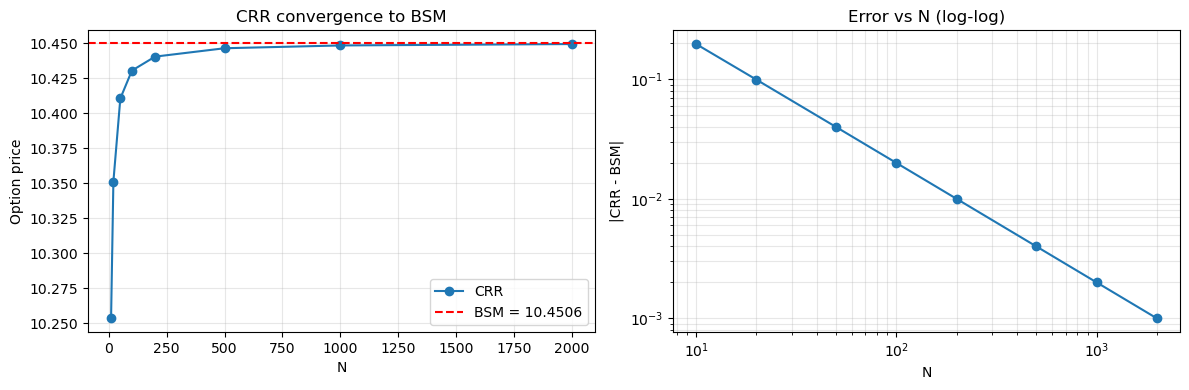


BSM = 10.450584
N=   10: CRR = 10.253409, error = 1.9717e-01
N=   20: CRR = 10.351260, error = 9.9323e-02
N=   50: CRR = 10.410692, error = 3.9892e-02
N=  100: CRR = 10.430612, error = 1.9972e-02
N=  200: CRR = 10.440591, error = 9.9923e-03
N=  500: CRR = 10.446585, error = 3.9984e-03
N= 1000: CRR = 10.448584, error = 1.9995e-03
N= 2000: CRR = 10.449584, error = 9.9980e-04


In [6]:
import matplotlib.pyplot as plt

Ns = [10, 20, 50, 100, 200, 500, 1000, 2000]
bsm = bsm_price(100, 100, 1.0, 0.05, 0.20, 'call')
crr_prices = np.array([crr_price(100, 100, 1.0, 0.05, 0.20, N, 'call') for N in Ns])
errors = np.abs(crr_prices - bsm)

# Two-panel plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(Ns, crr_prices, 'o-', label='CRR')
axes[0].axhline(bsm, color='red', linestyle='--', label=f'BSM = {bsm:.4f}')
axes[0].set_xlabel('N')
axes[0].set_ylabel('Option price')
axes[0].set_title('CRR convergence to BSM')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].loglog(Ns, errors, 'o-')
axes[1].set_xlabel('N')
axes[1].set_ylabel('|CRR - BSM|')
axes[1].set_title('Error vs N (log-log)')
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()
print(f"\nBSM = {bsm:.6f}")
for N, p, e in zip(Ns, crr_prices, errors):
    print(f"N={N:5d}: CRR = {p:.6f}, error = {e:.4e}")

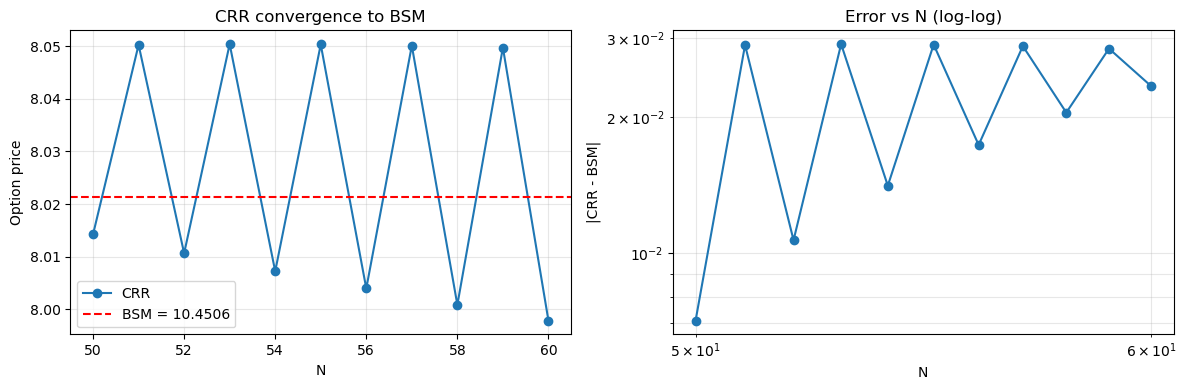

BSM OTM = 8.021352
N=50: CRR = 8.014263, error = -7.0893e-03
N=51: CRR = 8.050251, error = +2.8899e-02
N=52: CRR = 8.010671, error = -1.0681e-02
N=53: CRR = 8.050381, error = +2.9029e-02
N=54: CRR = 8.007251, error = -1.4101e-02
N=55: CRR = 8.050319, error = +2.8966e-02
N=56: CRR = 8.003990, error = -1.7362e-02
N=57: CRR = 8.050093, error = +2.8741e-02
N=58: CRR = 8.000876, error = -2.0476e-02
N=59: CRR = 8.049730, error = +2.8378e-02
N=60: CRR = 7.997898, error = -2.3454e-02


In [7]:
# Try a slightly OTM call
Ns = [50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
crr_otm = [crr_price(100, 105, 1.0, 0.05, 0.20, N, 'call') for N in Ns]
bsm_otm = bsm_price(100, 105, 1.0, 0.05, 0.20, 'call')
errors = np.abs(crr_otm - bsm_otm)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(Ns, crr_otm, 'o-', label='CRR')
axes[0].axhline(bsm_otm, color='red', linestyle='--', label=f'BSM = {bsm:.4f}')
axes[0].set_xlabel('N')
axes[0].set_ylabel('Option price')
axes[0].set_title('CRR convergence to BSM')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].loglog(Ns, errors, 'o-')
axes[1].set_xlabel('N')
axes[1].set_ylabel('|CRR - BSM|')
axes[1].set_title('Error vs N (log-log)')
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f"BSM OTM = {bsm_otm:.6f}")
for N, p in zip(range(50, 61), crr_otm):
    print(f"N={N}: CRR = {p:.6f}, error = {p - bsm_otm:+.4e}")

In [8]:
for N, e in zip(Ns, errors):
    print(f"N={N:5d}: error × N = {e*N:.4f}")

N=   50: error × N = 0.3545
N=   51: error × N = 1.4739
N=   52: error × N = 0.5554
N=   53: error × N = 1.5385
N=   54: error × N = 0.7615
N=   55: error × N = 1.5932
N=   56: error × N = 0.9723
N=   57: error × N = 1.6382
N=   58: error × N = 1.1876
N=   59: error × N = 1.6743
N=   60: error × N = 1.4072


Should be close to 2.0

Two practical consequences:

- You can't blindly use a single N value and trust the result. Always test convergence.
- For accurate pricing of OTM options, plain CRR is bad. The constant c in the c/N error can be large.

In [9]:
# A type of Fix: Richardson extrapolation
from models.binomial import crr_richardson

# Test on the OTM oscillation case
print(f"BSM OTM = {bsm_otm:.6f}")
for N in [50, 100, 200, 500]:
    p_crr = crr_price(100, 105, 1.0, 0.05, 0.20, N, 'call')
    p_rich = crr_richardson(100, 105, 1.0, 0.05, 0.20, N, 'call')
    print(f"N={N:4d}: CRR = {p_crr:.6f} (err {p_crr - bsm_otm:+.4e}), "
          f"Richardson = {p_rich:.6f} (err {p_rich - bsm_otm:+.4e})")

BSM OTM = 8.021352
N=  50: CRR = 8.014263 (err -7.0893e-03), Richardson = 8.038195 (err +1.6843e-02)
N= 100: CRR = 8.026229 (err +4.8768e-03), Richardson = 8.025771 (err +4.4189e-03)
N= 200: CRR = 8.026000 (err +4.6478e-03), Richardson = 8.025082 (err +3.7301e-03)
N= 500: CRR = 8.023176 (err +1.8238e-03), Richardson = 8.018945 (err -2.4077e-03)


In [10]:
print(f"BSM ATM = {bsm:.6f}")
for N in [50, 100, 200, 500]:
    p_crr = crr_price(100, 100, 1.0, 0.05, 0.20, N, 'call')
    p_rich = crr_richardson(100, 100, 1.0, 0.05, 0.20, N, 'call')
    print(f"N={N:4d}: CRR err = {p_crr - bsm:+.4e}, Richardson err = {p_rich - bsm:+.4e}")

BSM ATM = 10.450584
N=  50: CRR err = -3.9892e-02, Richardson err = -5.1788e-05
N= 100: CRR err = -1.9972e-02, Richardson err = -1.2715e-05
N= 200: CRR err = -9.9923e-03, Richardson err = -3.1495e-06
N= 500: CRR err = -3.9984e-03, Richardson err = -5.0110e-07


In [11]:
# Put-call parity for CRR
S, K, T, r, sigma = 100, 105, 1.0, 0.05, 0.20  # OTM where errors are large
for N in [10, 50, 100, 500]:
    c = crr_price(S, K, T, r, sigma, N, 'call')
    p = crr_price(S, K, T, r, sigma, N, 'put')
    residual = c - p - S + K * np.exp(-r * T)
    print(f"N={N:4d}: C-P-S+Ke^(-rT) = {residual:+.2e}")

N=  10: C-P-S+Ke^(-rT) = -1.14e-13
N=  50: C-P-S+Ke^(-rT) = +2.13e-13
N= 100: C-P-S+Ke^(-rT) = -8.53e-13
N= 500: C-P-S+Ke^(-rT) = +2.16e-12


You also see the residuals grow slightly with N. 1e-13 at N=10, 2e-12 at N=500. That's roundoff accumulation: more arithmetic operations, more chances for floating-point noise to leak in. Still all at machine precision relative to the magnitudes (~10), nothing to worry about.

In [12]:
from models.montecarlo import bsm_price_mc

price, se = bsm_price_mc(100, 100, 1.0, 0.05, 0.20, N=100_000, seed=42)
print(f"MC price: {price:.4f}")
print(f"MC SE:    {se:.4f}")
print(f"BSM:      10.4506")
print(f"95% CI:   [{price - 1.96*se:.4f}, {price + 1.96*se:.4f}]")

MC price: 10.4205
MC SE:    0.0468
BSM:      10.4506
95% CI:   [10.3289, 10.5122]
